<a href="https://colab.research.google.com/github/sarieibarra/My-New-Repo/blob/main/Detectando_firmas_de_enfermedad_en_expresion_g%C3%A9nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 🧬 Gene Expression Analysis for Cancer type Leukemia Classification

## 🎯 Objective
##Explore gene expression data to identify patterns that distinguish between two leukemia classes using statistical analysis and machine learning.

## 📊 Methods
## Exploratory Data Analysis (EDA)
## Dimensionality Reduction (PCA)
## Differential Gene Expression
## Classification Models
## Data Visualization & Storytelling

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Análisis de Datos/Leukemia_GSE14317.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,948,ATL,6.623031,6.808904,6.355542,8.247668,3.480459,9.125390,5.226010,4.341688,...,11.276918,11.119705,12.655236,12.530626,13.509183,12.465401,12.817112,3.319557,3.574506,3.486914
1,949,ATL,6.163962,7.988625,9.293418,7.566796,3.556427,8.935840,5.400994,4.481557,...,10.783528,10.817987,12.819174,13.043351,5.686440,4.061047,3.645543,3.221710,3.520820,3.440116
2,950,ATL,6.986526,6.892521,6.943873,8.494637,3.594590,7.116464,5.468954,4.467496,...,10.985585,10.820016,12.907073,13.169253,5.357096,4.428182,3.656504,3.158093,3.347842,3.465066
3,951,ATL,6.793723,6.809557,6.579995,8.085158,3.447432,7.286831,5.290462,4.374690,...,10.734938,10.707761,12.738497,13.060002,5.155394,4.199491,3.598697,3.233875,3.386033,3.527569
4,952,ATL,6.697826,6.701556,6.568722,8.112292,3.461497,7.666433,5.228273,4.301787,...,10.987972,10.935045,12.833202,13.161009,5.053338,4.088098,3.466760,3.151896,3.428925,3.431260


In [ ]:
df.shape

(25, 22279)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Columns: 22279 entries, samples to AFFX-TrpnX-M_at
dtypes: float64(22277), int64(1), object(1)
memory usage: 4.2+ MB


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.describe()

,samples,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,...,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,960.400000,6.509092,6.873442,7.658793,8.372769,3.579906,8.425133,5.416272,4.391633,8.661307,...,11.257468,11.246697,12.973161,13.137781,7.162674,6.303766,5.963211,3.239046,3.529617,3.476509
std,7.788881,0.426403,0.440207,1.873915,0.573837,0.089395,0.560493,0.227402,0.188909,1.352385,...,0.384065,0.415800,0.259609,0.356985,3.914478,3.581178,4.110645,0.070063,0.108259,0.094783
min,948.000000,5.889956,6.061699,6.140288,7.566796,3.424750,7.116464,5.045951,4.063735,5.865318,...,10.709666,10.678601,12.483829,12.164058,4.331524,4.051536,3.390458,3.083102,3.347842,3.253870
25%,954.000000,6.075273,6.701556,6.355542,7.986795,3.535766,8.040988,5.226010,4.254439,8.130736,...,10.985585,10.935045,12.833202,13.039545,4.565822,4.190315,3.469427,3.197993,3.463818,3.440116
50%,960.000000,6.558206,6.809557,6.604629,8.247668,3.566646,8.557065,5.400994,4.388562,8.916096,...,11.176997,11.177792,12.994549,13.169253,5.053338,4.269321,3.580444,3.233875,3.544956,3.465066
75%,967.000000,6.703310,7.030323,8.421531,8.765390,3.616542,8.919791,5.517156,4.481557,9.428705,...,11.528531,11.447291,13.150606,13.415216,8.257800,6.916397,7.109095,3.297713,3.564989,3.527569
max,973.000000,7.368969,7.988625,11.841921,9.374846,3.807859,9.125390,5.904684,4.858967,11.854345,...,12.115229,12.291667,13.603983,13.748824,14.153389,13.472466,13.500055,3.347933,3.803586,3.641171


# **Preparación de Datos**

In [ ]:
X = df.drop(["samples", "type"], axis=1)
y = df["type"]

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



Exploratory Data Analysis

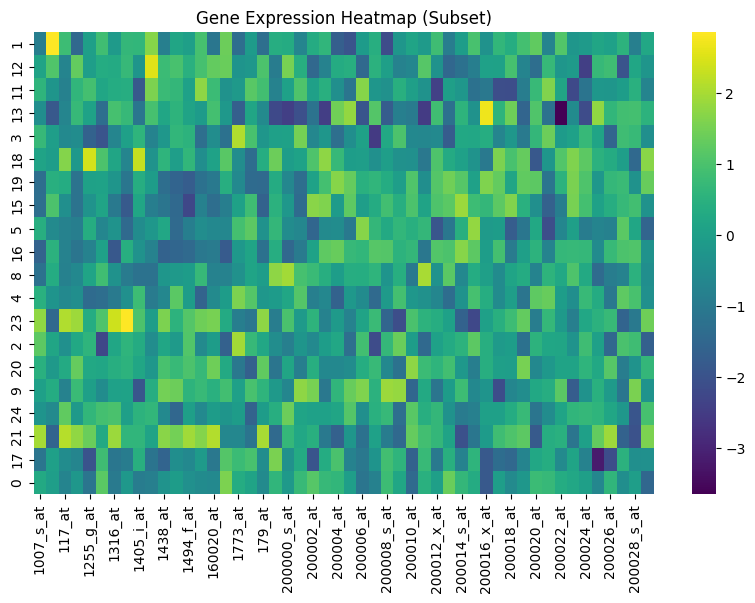

In [ ]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)
plt.figure(figsize=(10,6))

sns.heatmap(X_train_scaled.iloc[:, :50], cmap="viridis")

plt.title("Gene Expression Heatmap (Subset)")
plt.show()



PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

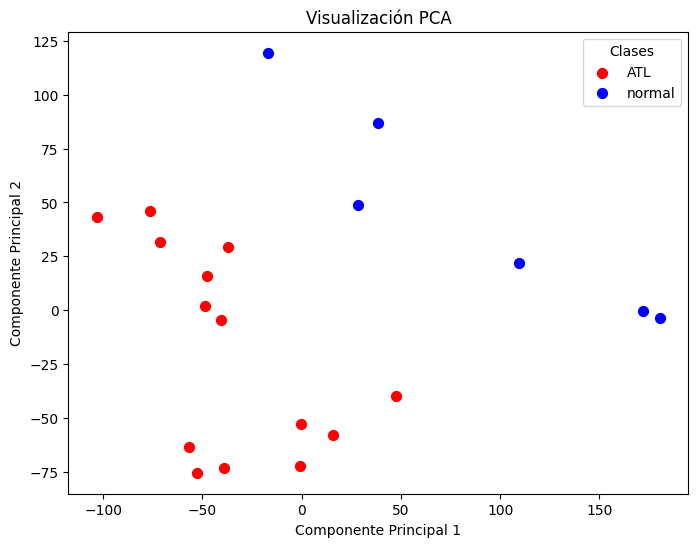

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y_train)

# Colores para cada clase
colors = ['red', 'blue']

plt.figure(figsize=(8,6))

# Graficar cada clase por separado
for i, label in enumerate(le.classes_):

    idx = y_encoded == i

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        color=colors[i],
        label=label,
        s=50
    )

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Visualización PCA')

plt.legend(title="Clases")

plt.show()






##  Interpretation

PCA shows whether the two classes (tumor types) are separable in reduced dimensional space.

Clear separation → strong biological signal  
Overlap → more complex gene regulation patterns

In [ ]:

# dividir
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# escalar
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# modelo
model = LogisticRegression(max_iter=1000)

# entrenar
model.fit(X_train_scaled, y_train)

# predecir
y_pred = model.predict(X_test_scaled)



In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ATL       1.00      1.00      1.00         4
      normal       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [ ]:
coefficients = pd.Series(model.coef_[0])
top_genes = coefficients.abs().sort_values(ascending=False).head(20)
top_genes

,0
18542,0.002921
15504,0.002879
4017,0.002842
16226,0.002842
3243,0.002819
12553,0.002814
13417,0.002807
15141,0.002795
3211,0.002787
8630,0.002774


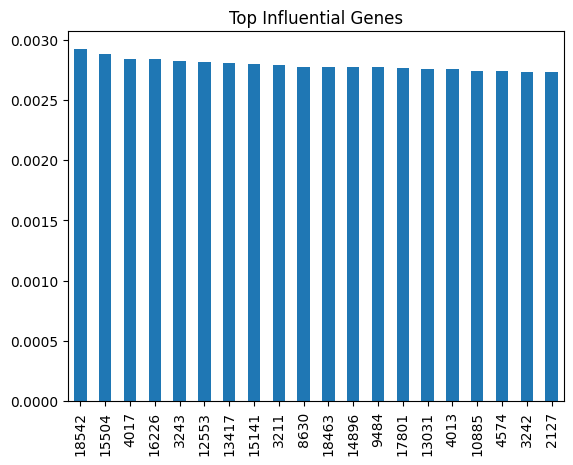

In [ ]:
top_genes.plot(kind="bar")
plt.title("Top Influential Genes")
plt.show()

## 🧾 Conclusions

- Gene expression patterns allow partial separation between classes
- PCA reveals structure in high-dimensional biological data
- Simple ML models can capture meaningful signal
- Top genes may represent potential biomarkers